In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn 
import torch.optim as optim
device = torch.device('cuda')
torch.manual_seed(42)

In [3]:
torch.cuda.is_available()

True

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/mostafizcse007/Deep-Learning/refs/heads/main/Week%203/student_placement_synthetic.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [5]:
try:
  df.drop(columns=['salary_package_lpa'],inplace=True)
except:
  pass

In [6]:
df['branch'] = df['branch'].astype('category')
df['college_tier'] = df['college_tier'].astype('category')

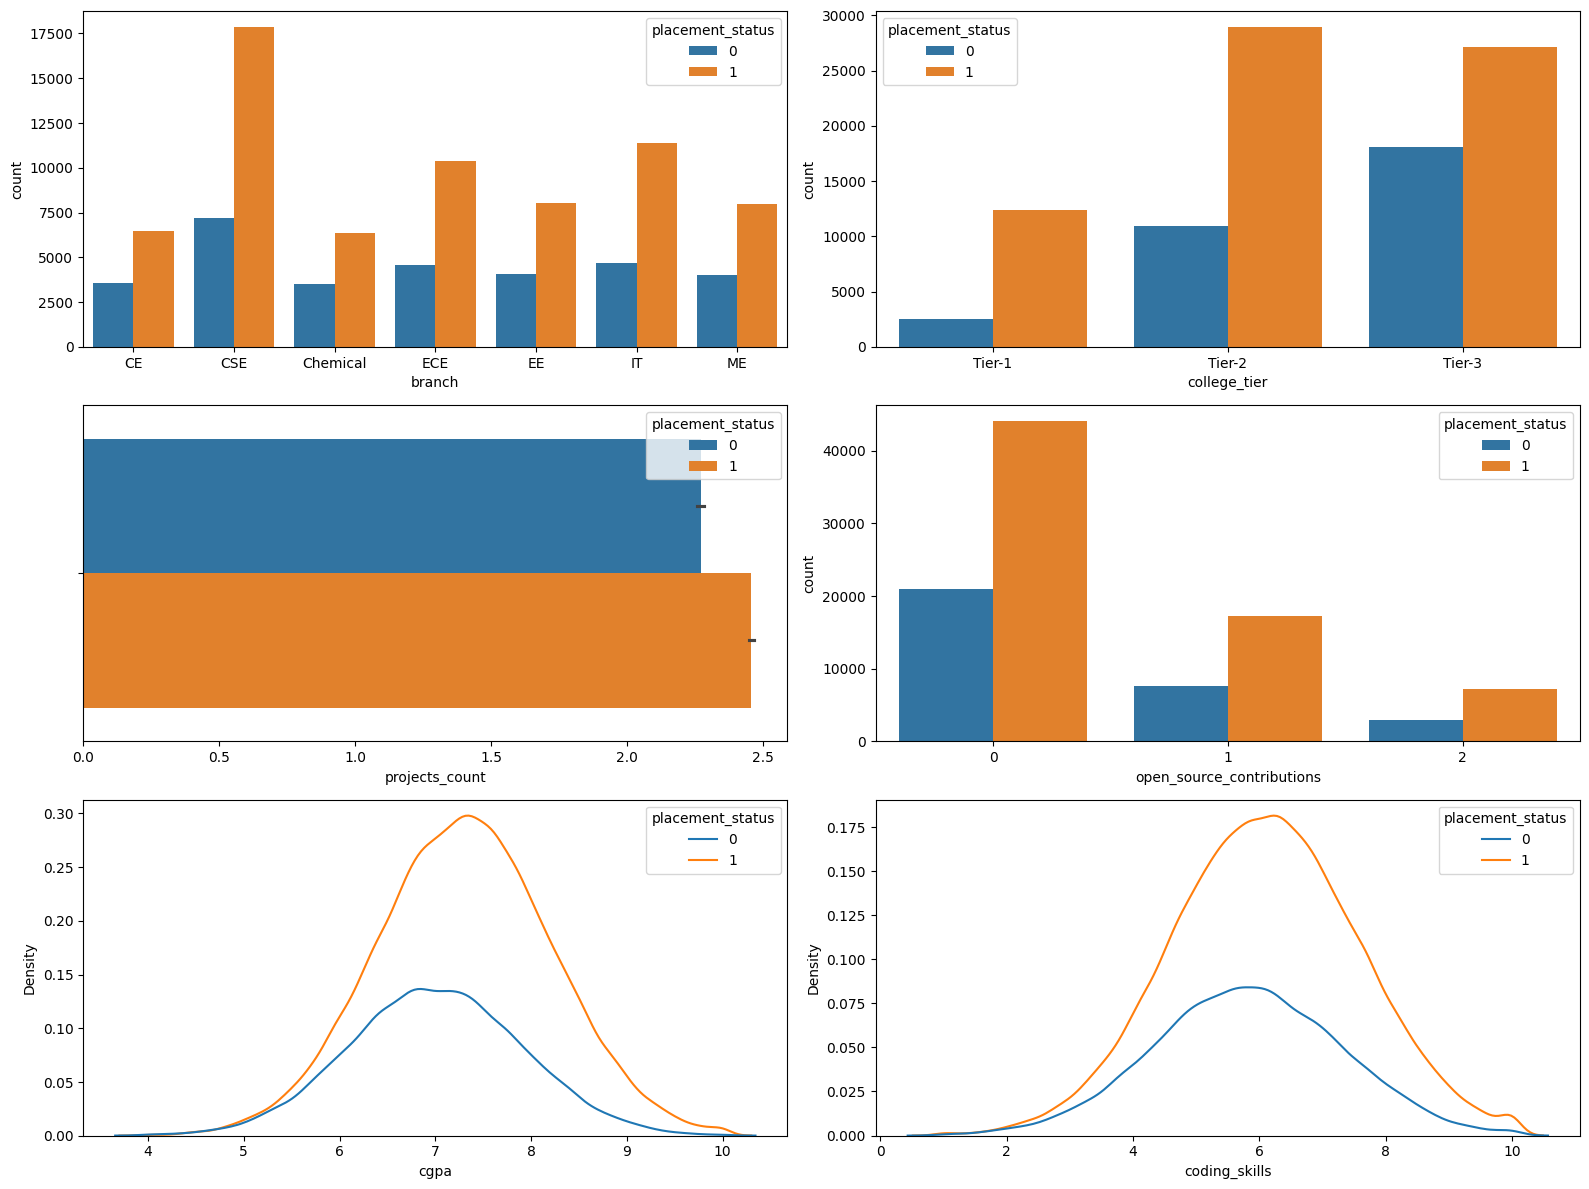

In [7]:
fig,axes = plt.subplots(3,2,figsize=(16,12))
sns.countplot(data=df,x='branch',ax=axes[0,0],hue='placement_status')
sns.countplot(data=df,x='college_tier',ax=axes[0,1],hue='placement_status')
sns.barplot(data=df,x='projects_count',ax=axes[1,0],hue='placement_status')
sns.countplot(data=df,x='open_source_contributions',ax=axes[1,1],hue='placement_status')
sns.kdeplot(data=df,x='cgpa',ax=axes[2,0],hue='placement_status')
sns.kdeplot(data=df,x='coding_skills',ax=axes[2,1],hue='placement_status')
plt.tight_layout()
plt.show()

In [8]:
df = pd.get_dummies(df, columns=['branch','college_tier'], drop_first=True)

In [9]:
num_cols = df.select_dtypes(['int','float']).columns

In [10]:
df[num_cols].corr()['placement_status'].sort_values(ascending=False)

,placement_status
placement_status,1.000000
cgpa,0.148932
internships,0.099967
coding_skills,0.087657
dsa_score,0.086594
projects_count,0.069900
certifications,0.055636
communication_skills,0.051034
aptitude_score,0.045146
hackathons,0.033315


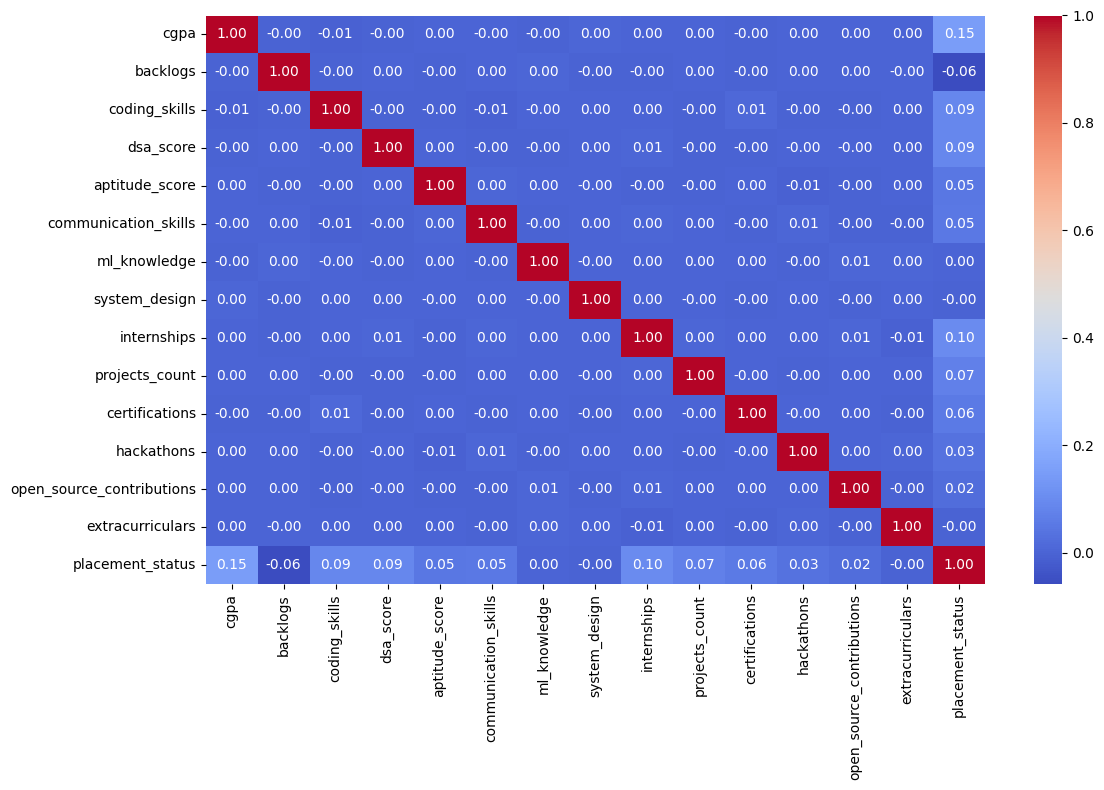

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),fmt='.2f',cmap='coolwarm',annot=True)
plt.tight_layout()
plt.show()

In [12]:
X = df.drop(columns=['placement_status'])
y = df['placement_status']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [14]:
num_cols = X.select_dtypes(['int','float','bool']).columns

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
y_train = torch.tensor(y_train.values,dtype=torch.long)
y_test = torch.tensor(y_test.values,dtype=torch.long)

In [17]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return len(self.features)

    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]

In [18]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [19]:
train_loader = DataLoader(train_dataset,shuffle=True,batch_size=32,pin_memory=True)
test_loader = DataLoader(test_dataset,shuffle=False,batch_size=32,pin_memory=True)

In [23]:
class ANN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=.3),
            nn.Linear(32,16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(p=.3),
            nn.Linear(16,8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(p=.3),
            nn.Linear(8,1)
        )
    
    def forward(self,X):
        return self.model(X)

In [21]:
epochs = 100
learning_rate = .001

In [22]:
model = ANN(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-4)

TypeError: Sigmoid.__init__() takes 1 positional argument but 3 were given

In [ ]:
for epoch in range(epochs):
    epoch_loss = 0

    for batch_feature,batch_label in train_loader:
        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device).unsqueeze(1).float()

        outputs = model(batch_feature)
        loss = criterion(outputs,batch_label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: {epoch_loss/len(train_loader)}")

Epoch 10: 0.5848026522278785
Epoch 20: 0.5836960846304894
Epoch 30: 0.5842362427830696
Epoch 40: 0.5848562603116035
Epoch 50: 0.5845440296769142
Epoch 60: 0.5847488436222077
Epoch 70: 0.5840177902221679
Epoch 80: 0.5848615824937821
Epoch 90: 0.5848669114351273
Epoch 100: 0.5852786670804023


In [ ]:
model.eval()

total = 0
correct = 0
with torch.no_grad():
    for batch_feature, batch_label in train_loader:

        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_feature)

        predicted = (outputs.squeeze() >= 0).long()

        total += batch_feature.shape[0]
        correct += (predicted == batch_label).sum().item()

print(correct / total)

0.6985625


In [ ]:
model.eval()

total = 0
correct = 0
with torch.no_grad():
    for batch_feature, batch_label in test_loader:

        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_feature)

        predicted = (outputs.squeeze() >= 0).long()

        total += batch_feature.shape[0]
        correct += (predicted == batch_label).sum().item()

print(correct / total)

0.6969
